In [1]:
import json
import random
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap

TRAIN_DIR = Path("dataset/fracture_segmentation/train")
VAL_DIR = Path("dataset/fracture_segmentation/validation")

CSM_CMAP = ListedColormap(["black", "steelblue", "crimson"])
CSM_NORM = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], ncolors=3)
CSM_LEGEND = [
    mpatches.Patch(color="black", label="0 – background"),
    mpatches.Patch(color="steelblue", label="1 – foreground"),
    mpatches.Patch(color="crimson", label="2 – contact surface"),
]

In [2]:
# ── Folder structure & counts ─────────────────────────────────────────────────

for split, split_dir in [("train", TRAIN_DIR), ("validation", VAL_DIR)]:
    files = sorted(split_dir.glob("patient_*.npz"))
    meta_ok = (split_dir / "metadata.json").exists()

    bone_counts = {}
    for f in files:
        # stem: patient_001_sacrum  or  patient_001_left_hip
        bone = "_".join(f.stem.split("_")[2:])
        bone_counts[bone] = bone_counts.get(bone, 0) + 1

    print(
        f"[{split}]  {len(files)} files   metadata.json: {'✓' if meta_ok else '✗ MISSING'}"
    )
    for bone, n in sorted(bone_counts.items()):
        print(f"  {bone:12s}: {n}")
    print()

[train]  940 files   metadata.json: ✓
  femur_patch_00: 136
  femur_patch_01: 133
  left_hip_patch_00: 136
  left_hip_patch_01: 95
  right_hip_patch_00: 136
  right_hip_patch_01: 93
  sacrum_patch_00: 136
  sacrum_patch_01: 75

[validation]  136 files   metadata.json: ✓
  femur       : 34
  left_hip    : 34
  right_hip   : 34
  sacrum      : 34



[train]  272 patients, 544 bone cases
  fragments — min 1  max 23  mean 3.5
  femur       : 136 cases  frags 2–11  mean 3.5
  left_hip    : 136 cases  frags 1–16  mean 3.8
  right_hip   : 136 cases  frags 1–23  mean 3.9
  sacrum      : 136 cases  frags 1–15  mean 2.9

[validation]  68 patients, 136 bone cases
  fragments — min 1  max 16  mean 3.8
  femur       : 34 cases  frags 2–8  mean 3.5
  left_hip    : 34 cases  frags 1–16  mean 4.9
  right_hip   : 34 cases  frags 1–13  mean 3.3
  sacrum      : 34 cases  frags 1–15  mean 3.6



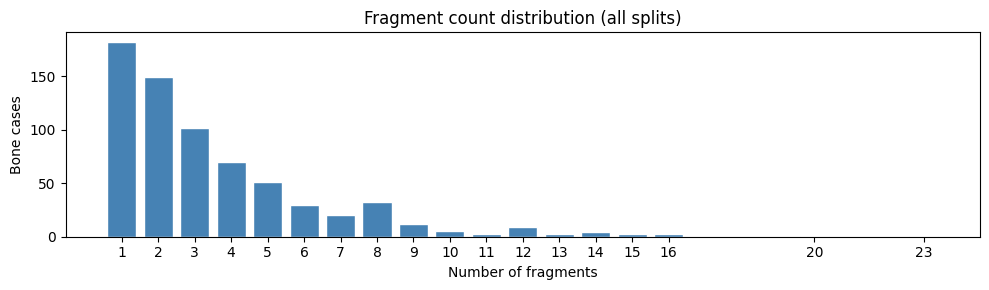

In [3]:
# ── Metadata stats & fragment distribution ────────────────────────────────────

for split, split_dir in [("train", TRAIN_DIR), ("validation", VAL_DIR)]:
    meta_path = split_dir / "metadata.json"
    if not meta_path.exists():
        print(f"[{split}] metadata.json missing — skipping")
        continue

    records = json.loads(meta_path.read_text())
    all_frags = [b["num_fragments"] for r in records for b in r["bones"]]

    print(f"[{split}]  {len(records)} patients, {len(all_frags)} bone cases")
    print(
        f"  fragments — min {min(all_frags)}  max {max(all_frags)}  mean {sum(all_frags) / len(all_frags):.1f}"
    )

    bone_frag = {}
    for r in records:
        for b in r["bones"]:
            bone_frag.setdefault(b["bone"], []).append(b["num_fragments"])
    for bone, frags in sorted(bone_frag.items()):
        print(
            f"  {bone:12s}: {len(frags)} cases  frags {min(frags)}–{max(frags)}  mean {sum(frags) / len(frags):.1f}"
        )
    print()

# Fragment count histogram (all splits combined)
all_frags_combined = []
for split_dir in [TRAIN_DIR, VAL_DIR]:
    meta_path = split_dir / "metadata.json"
    if meta_path.exists():
        records = json.loads(meta_path.read_text())
        all_frags_combined.extend(
            b["num_fragments"] for r in records for b in r["bones"]
        )

counts = {}
for f in all_frags_combined:
    counts[f] = counts.get(f, 0) + 1
xs, ys = zip(*sorted(counts.items()))

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(xs, ys, color="steelblue", edgecolor="white")
ax.set_xlabel("Number of fragments")
ax.set_ylabel("Bone cases")
ax.set_title("Fragment count distribution (all splits)")
ax.set_xticks(xs)
plt.tight_layout()
plt.show()

In [4]:
def check_sample(path):
    data = np.load(path)
    image = data["image"]  # (1, D, H, W)  float32
    csm = data["csm"]  # (1, D, H, W)  uint8

    total = csm.size
    print(f"\n{path.name}")
    print(f"  image shape  : {image.shape}   dtype: {image.dtype}")
    print(f"  csm shape    : {csm.shape}   dtype: {csm.dtype}")
    print(
        f"  image        : min {image.min():.3f}  max {image.max():.3f}  mean {image.mean():.3f}"
    )
    print(f"  csm unique   : {np.unique(csm).tolist()}")
    for val, name in [(0, "background"), (1, "foreground"), (2, "contact")]:
        n = (csm == val).sum()
        print(f"    {val} ({name:12s}): {n:>10,}  ({100 * n / total:.1f}%)")

    return image, csm

In [5]:
def visualise_volume_slices(image, csm, title="Volume", num_slices=6):
    """Show evenly-spaced slices along the depth axis."""
    img = image[0]  # (D, H, W)
    seg = csm[0]

    D = img.shape[0]
    indices = np.linspace(0, D - 1, num_slices, dtype=int)

    fig, axes = plt.subplots(3, num_slices, figsize=(18, 9))
    fig.suptitle(title)

    for i, s in enumerate(indices):
        # Row 0: image
        axes[0, i].imshow(img[s], cmap="gray", vmin=0, vmax=1)
        axes[0, i].set_title(f"slice {s}")
        axes[0, i].axis("off")

        # Row 1: CSM
        axes[1, i].imshow(seg[s], cmap=CSM_CMAP, norm=CSM_NORM)
        axes[1, i].set_title(f"CSM {s}")
        axes[1, i].axis("off")

        # Row 2: overlay
        axes[2, i].imshow(img[s], cmap="gray", vmin=0, vmax=1)
        overlay = np.zeros((*seg[s].shape, 4))
        overlay[seg[s] == 1] = [0.27, 0.51, 0.71, 0.35]
        overlay[seg[s] == 2] = [0.86, 0.08, 0.24, 0.70]
        axes[2, i].imshow(overlay)
        axes[2, i].set_title(f"overlay {s}")
        axes[2, i].axis("off")

    axes[0, 0].set_ylabel("Image", fontsize=9)
    axes[1, 0].set_ylabel("CSM", fontsize=9)
    axes[2, 0].set_ylabel("Overlay", fontsize=9)
    axes[1, -1].legend(
        handles=CSM_LEGEND, loc="upper right", fontsize=7, framealpha=0.7
    )

    plt.tight_layout()
    plt.show()

In [6]:
def visualise_centre_slices(image, csm, title="Sample"):
    """Show centre slices on all three axes: axial, coronal, sagittal."""
    img = image[0]  # (D, H, W)
    seg = csm[0]

    D, H, W = img.shape
    slices_img = [img[D // 2], img[:, H // 2, :], img[:, :, W // 2]]
    slices_csm = [seg[D // 2], seg[:, H // 2, :], seg[:, :, W // 2]]
    views = [f"Axial (d={D // 2})", f"Coronal (h={H // 2})", f"Sagittal (w={W // 2})"]

    fig, axes = plt.subplots(3, 3, figsize=(14, 12))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for col, (sl_img, sl_csm, view) in enumerate(zip(slices_img, slices_csm, views)):
        axes[0, col].imshow(sl_img, cmap="gray", vmin=0, vmax=1)
        axes[0, col].set_title(f"{view} — image")
        axes[0, col].axis("off")

        axes[1, col].imshow(sl_csm, cmap=CSM_CMAP, norm=CSM_NORM)
        axes[1, col].set_title(f"{view} — CSM")
        axes[1, col].axis("off")

        axes[2, col].imshow(sl_img, cmap="gray", vmin=0, vmax=1)
        overlay = np.zeros((*sl_csm.shape, 4))
        overlay[sl_csm == 1] = [0.27, 0.51, 0.71, 0.35]
        overlay[sl_csm == 2] = [0.86, 0.08, 0.24, 0.70]
        axes[2, col].imshow(overlay)
        axes[2, col].set_title(f"{view} — overlay")
        axes[2, col].axis("off")

    axes[0, 0].set_ylabel("Image", fontsize=10)
    axes[1, 0].set_ylabel("CSM", fontsize=10)
    axes[2, 0].set_ylabel("Overlay", fontsize=10)
    axes[1, -1].legend(
        handles=CSM_LEGEND, loc="upper right", fontsize=7, framealpha=0.7
    )

    plt.tight_layout()
    plt.show()

Total training volumes: 940

patient_129_sacrum_patch_00.npz
  image shape  : (1, 96, 96, 96)   dtype: float32
  csm shape    : (1, 96, 96, 96)   dtype: uint8
  image        : min 0.000  max 0.836  mean 0.045
  csm unique   : [0, 1]
    0 (background  ):    727,371  (82.2%)
    1 (foreground  ):    157,365  (17.8%)
    2 (contact     ):          0  (0.0%)


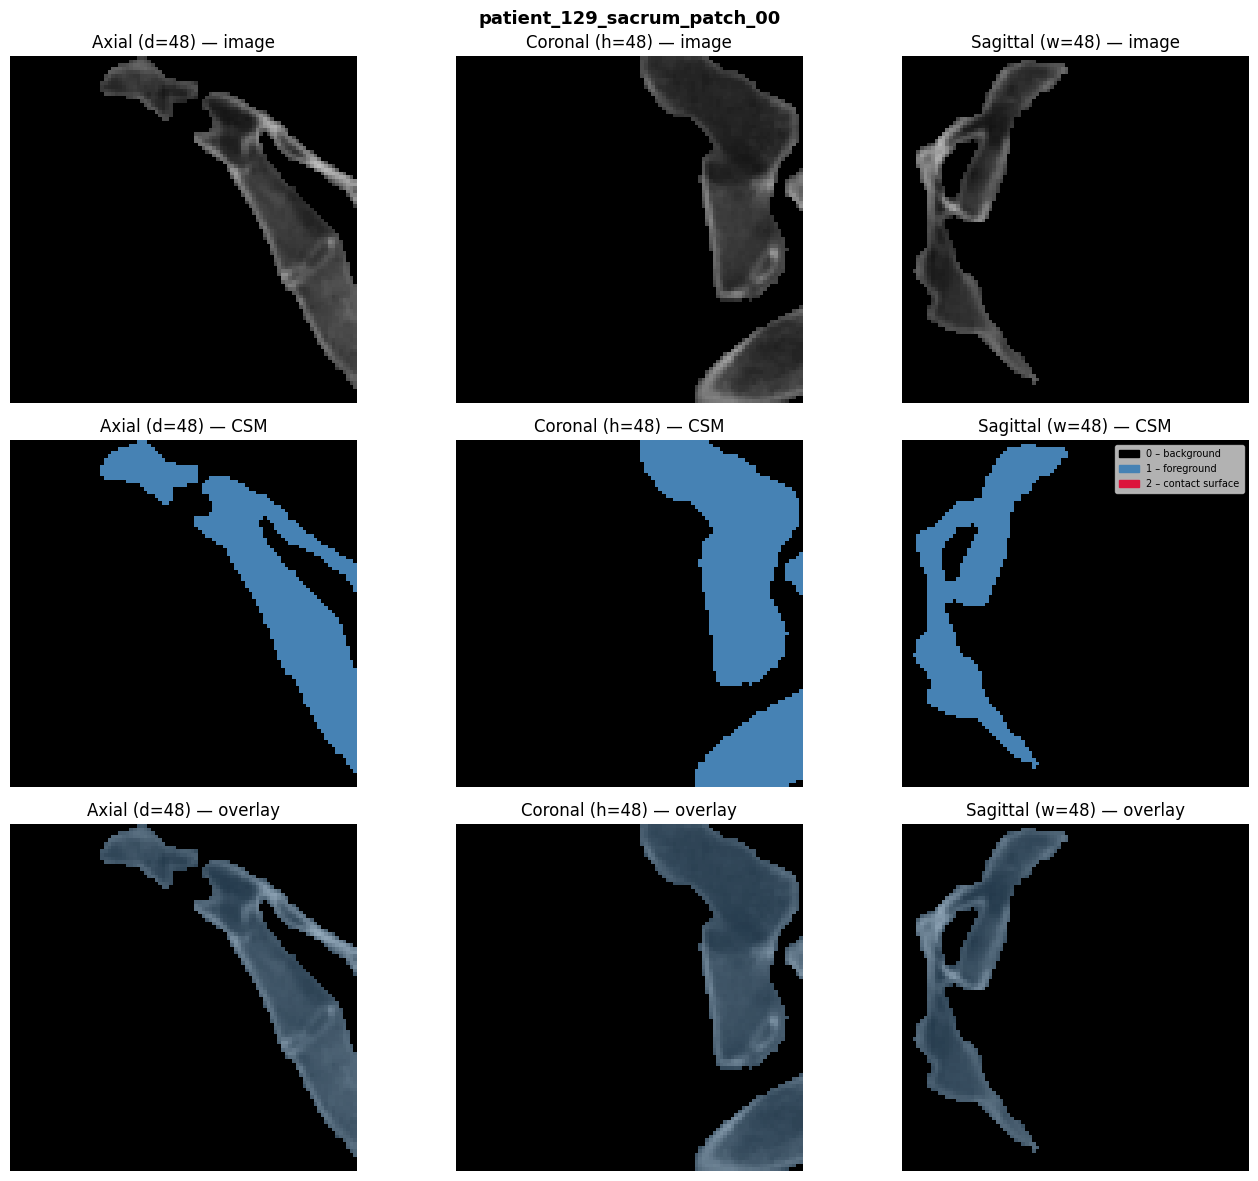


patient_072_right_hip_patch_00.npz
  image shape  : (1, 96, 96, 96)   dtype: float32
  csm shape    : (1, 96, 96, 96)   dtype: uint8
  image        : min 0.000  max 0.980  mean 0.045
  csm unique   : [0, 1, 2]
    0 (background  ):    779,908  (88.2%)
    1 (foreground  ):    102,314  (11.6%)
    2 (contact     ):      2,514  (0.3%)


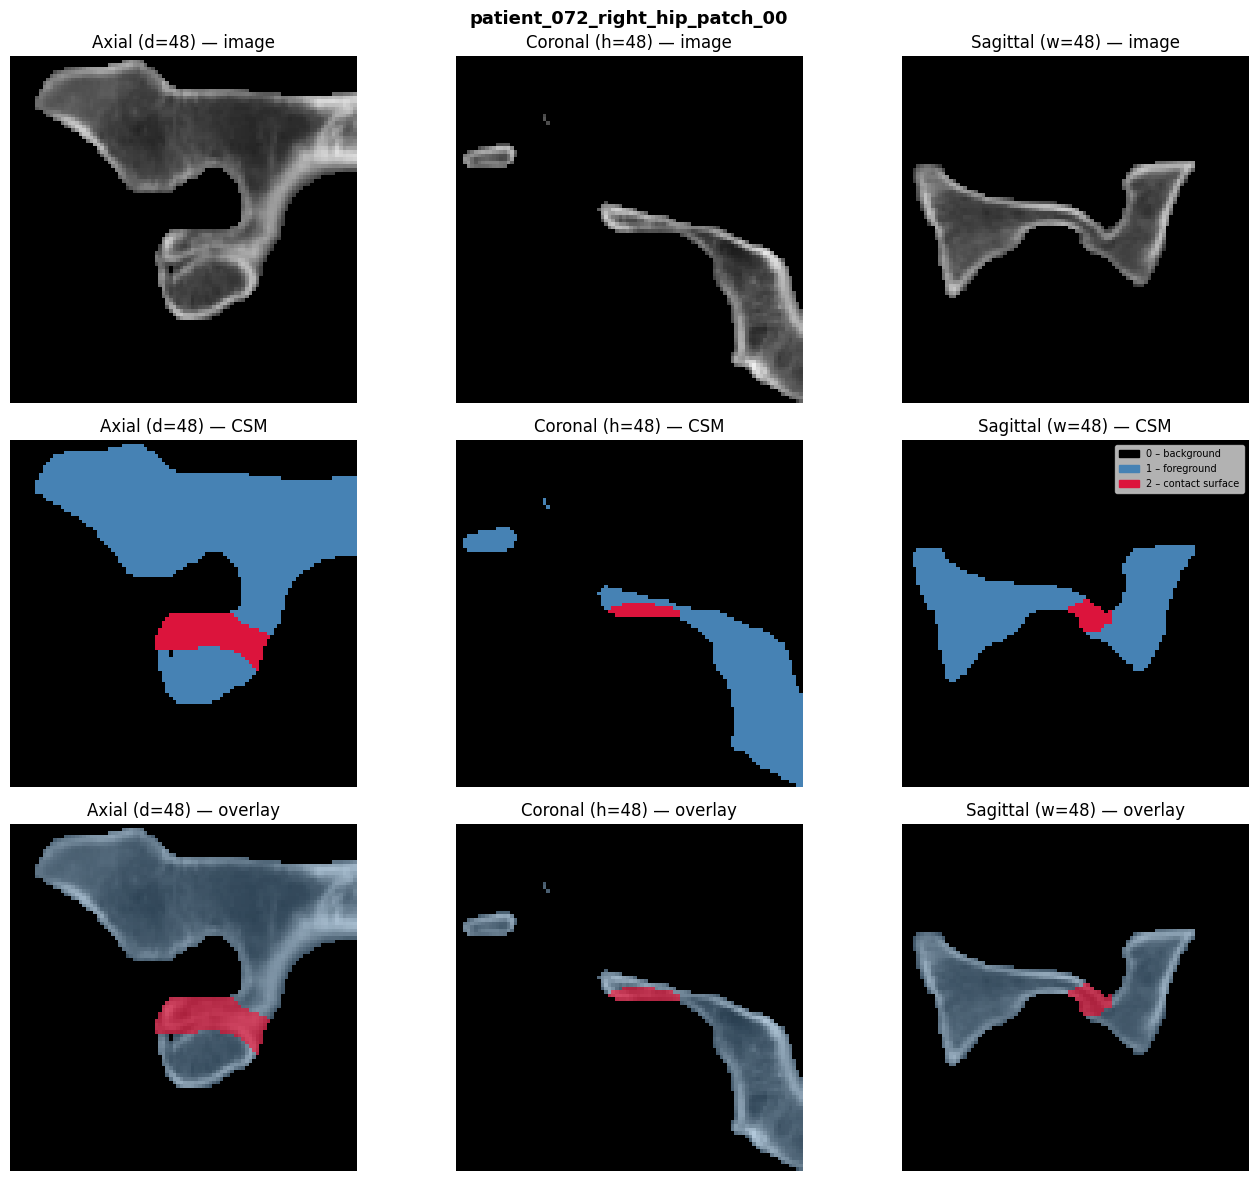


patient_103_right_hip_patch_00.npz
  image shape  : (1, 96, 96, 96)   dtype: float32
  csm shape    : (1, 96, 96, 96)   dtype: uint8
  image        : min 0.000  max 1.000  mean 0.045
  csm unique   : [0, 1, 2]
    0 (background  ):    751,880  (85.0%)
    1 (foreground  ):    122,344  (13.8%)
    2 (contact     ):     10,512  (1.2%)


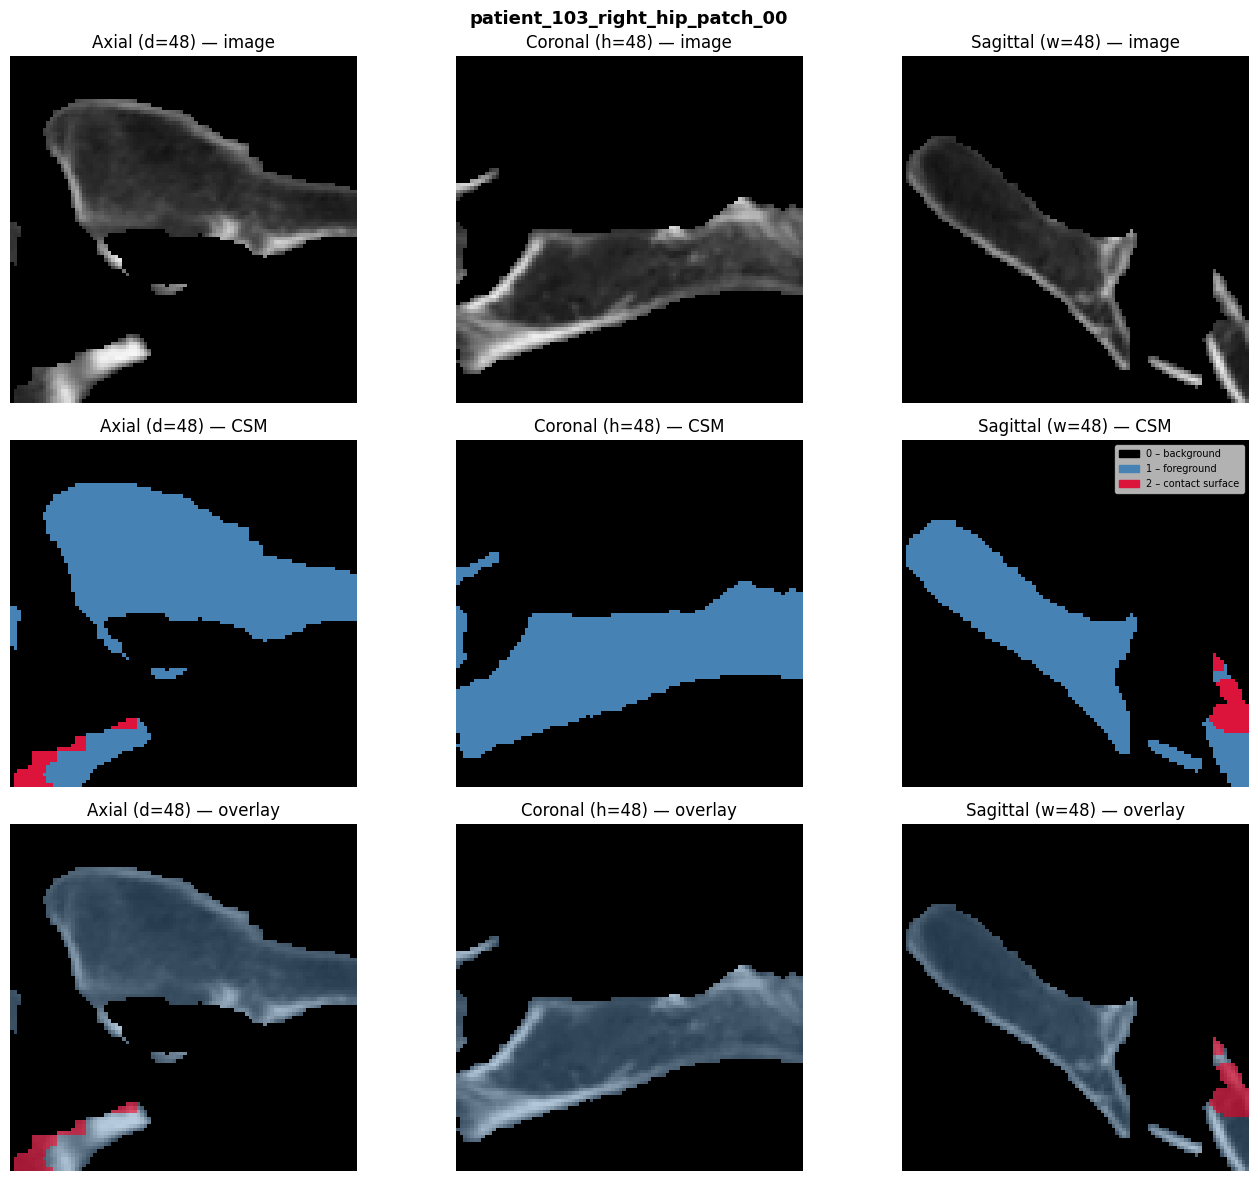

In [7]:
# ── Check random training samples ─────────────────────────────────────────────

train_files = sorted(TRAIN_DIR.glob("patient_*.npz"))
print(f"Total training volumes: {len(train_files)}")

for path in random.sample(train_files, min(3, len(train_files))):
    image, csm = check_sample(path)
    visualise_centre_slices(image, csm, title=path.stem)

Total validation volumes: 136

patient_282_sacrum.npz
  image shape  : (1, 147, 102, 138)   dtype: float32
  csm shape    : (1, 147, 102, 138)   dtype: uint8
  image        : min 0.000  max 0.889  mean 0.026
  csm unique   : [0, 1, 2]
    0 (background  ):  1,881,088  (90.9%)
    1 (foreground  ):    181,533  (8.8%)
    2 (contact     ):      6,551  (0.3%)


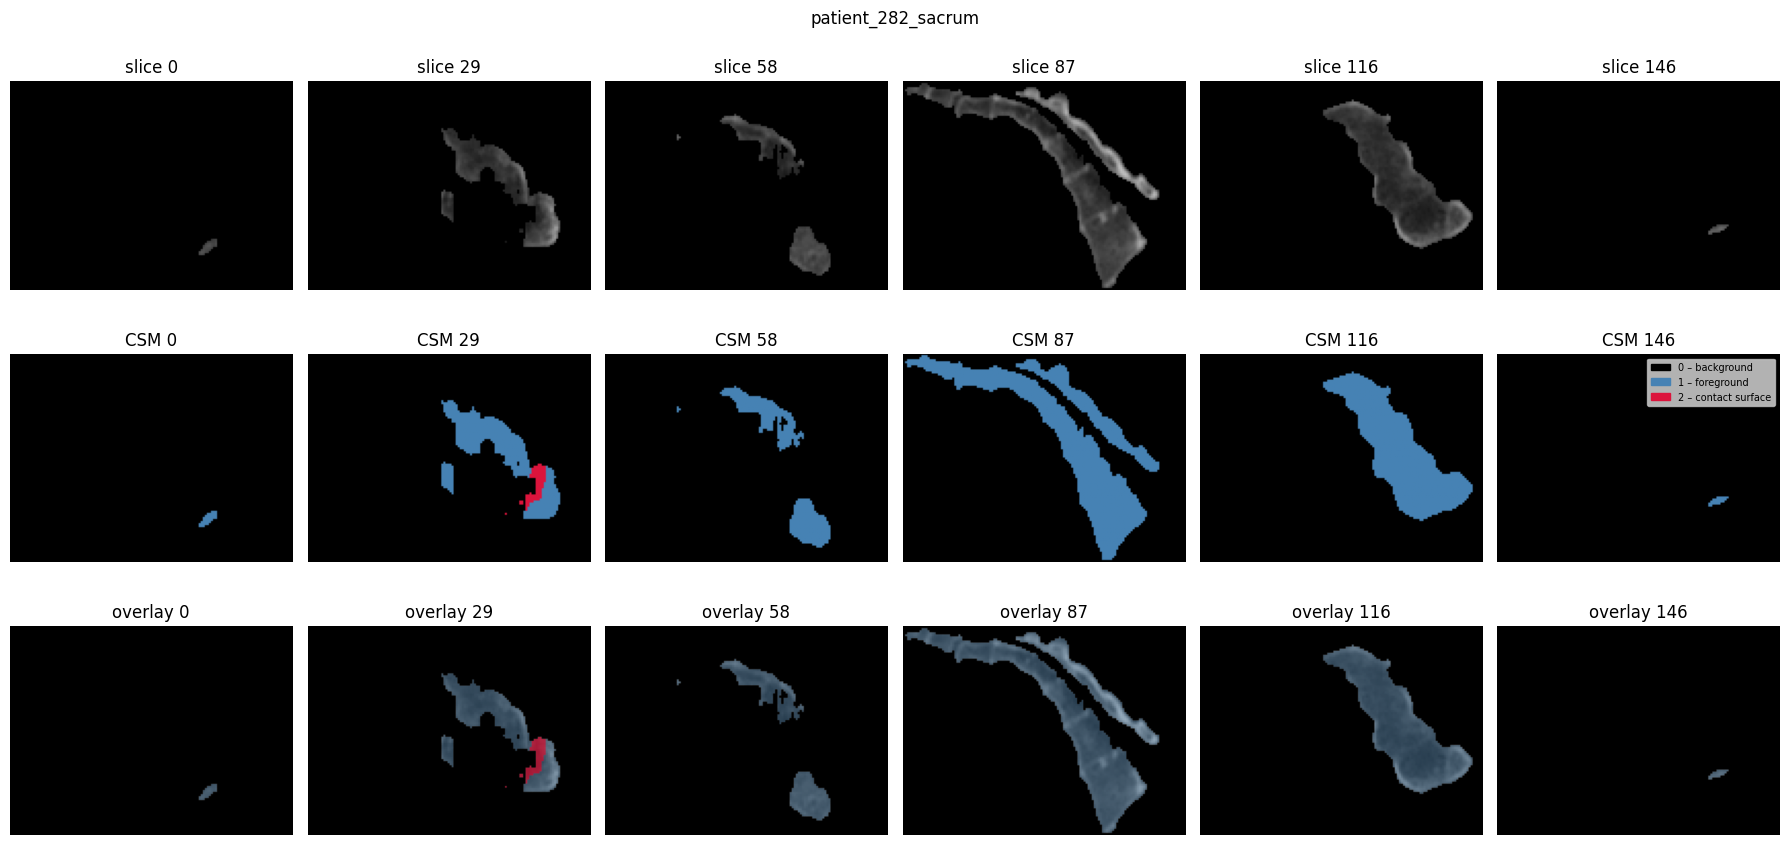


patient_302_left_hip.npz
  image shape  : (1, 133, 148, 214)   dtype: float32
  csm shape    : (1, 133, 148, 214)   dtype: uint8
  image        : min 0.000  max 0.891  mean 0.030
  csm unique   : [0, 1]
    0 (background  ):  3,882,376  (92.2%)
    1 (foreground  ):    330,000  (7.8%)
    2 (contact     ):          0  (0.0%)


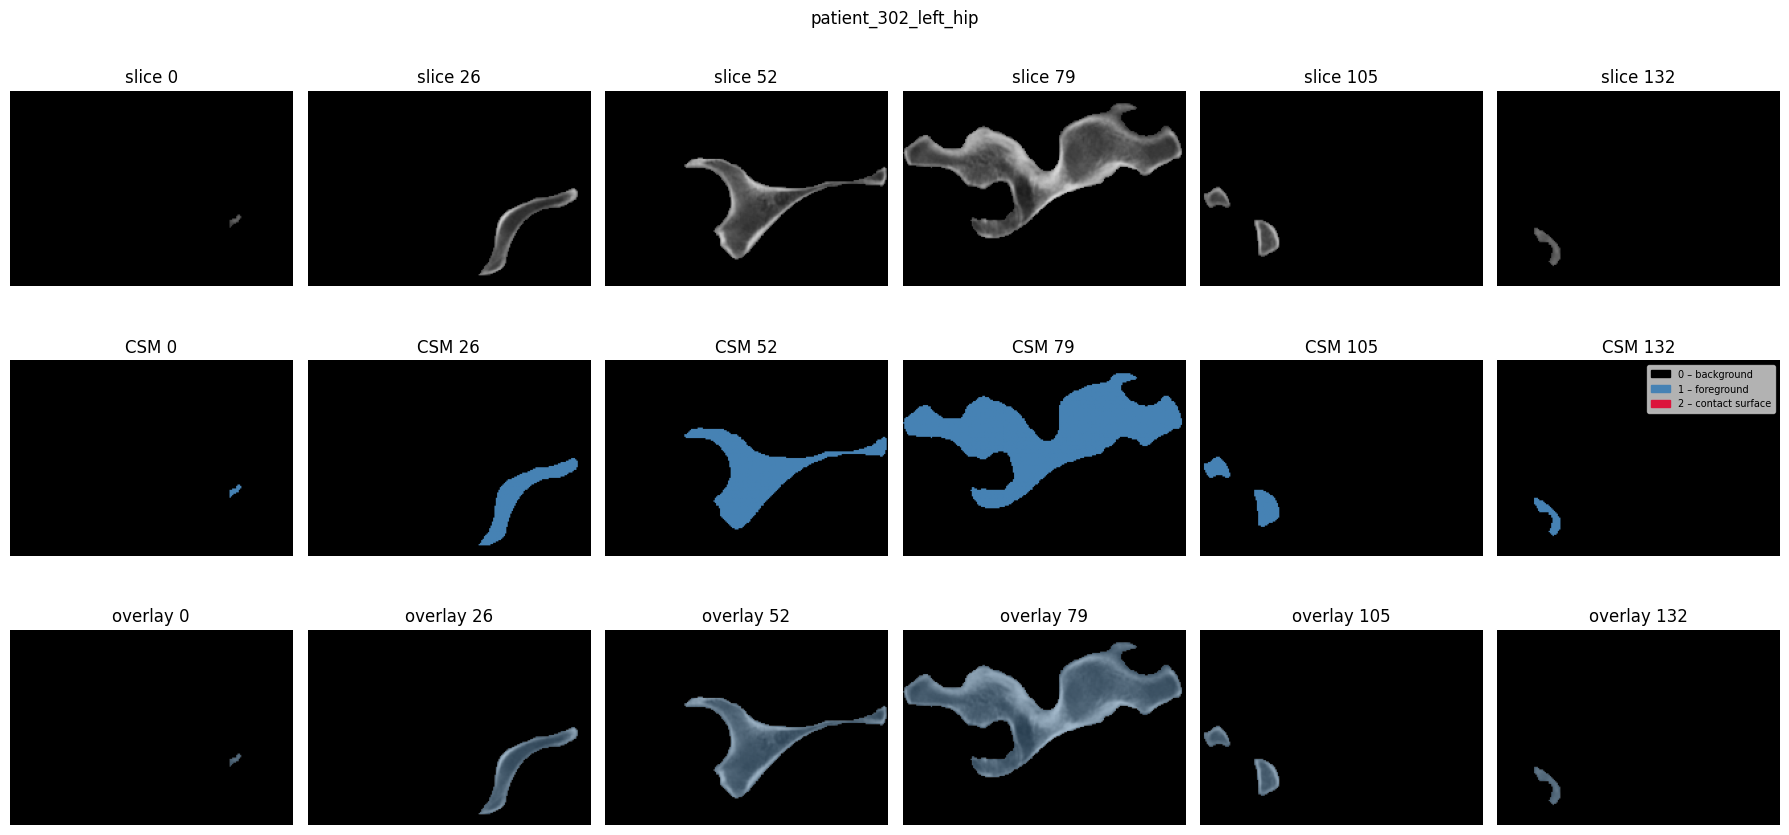


patient_273_left_hip.npz
  image shape  : (1, 139, 138, 211)   dtype: float32
  csm shape    : (1, 139, 138, 211)   dtype: uint8
  image        : min 0.000  max 1.000  mean 0.032
  csm unique   : [0, 1, 2]
    0 (background  ):  3,708,316  (91.6%)
    1 (foreground  ):    325,020  (8.0%)
    2 (contact     ):     14,066  (0.3%)


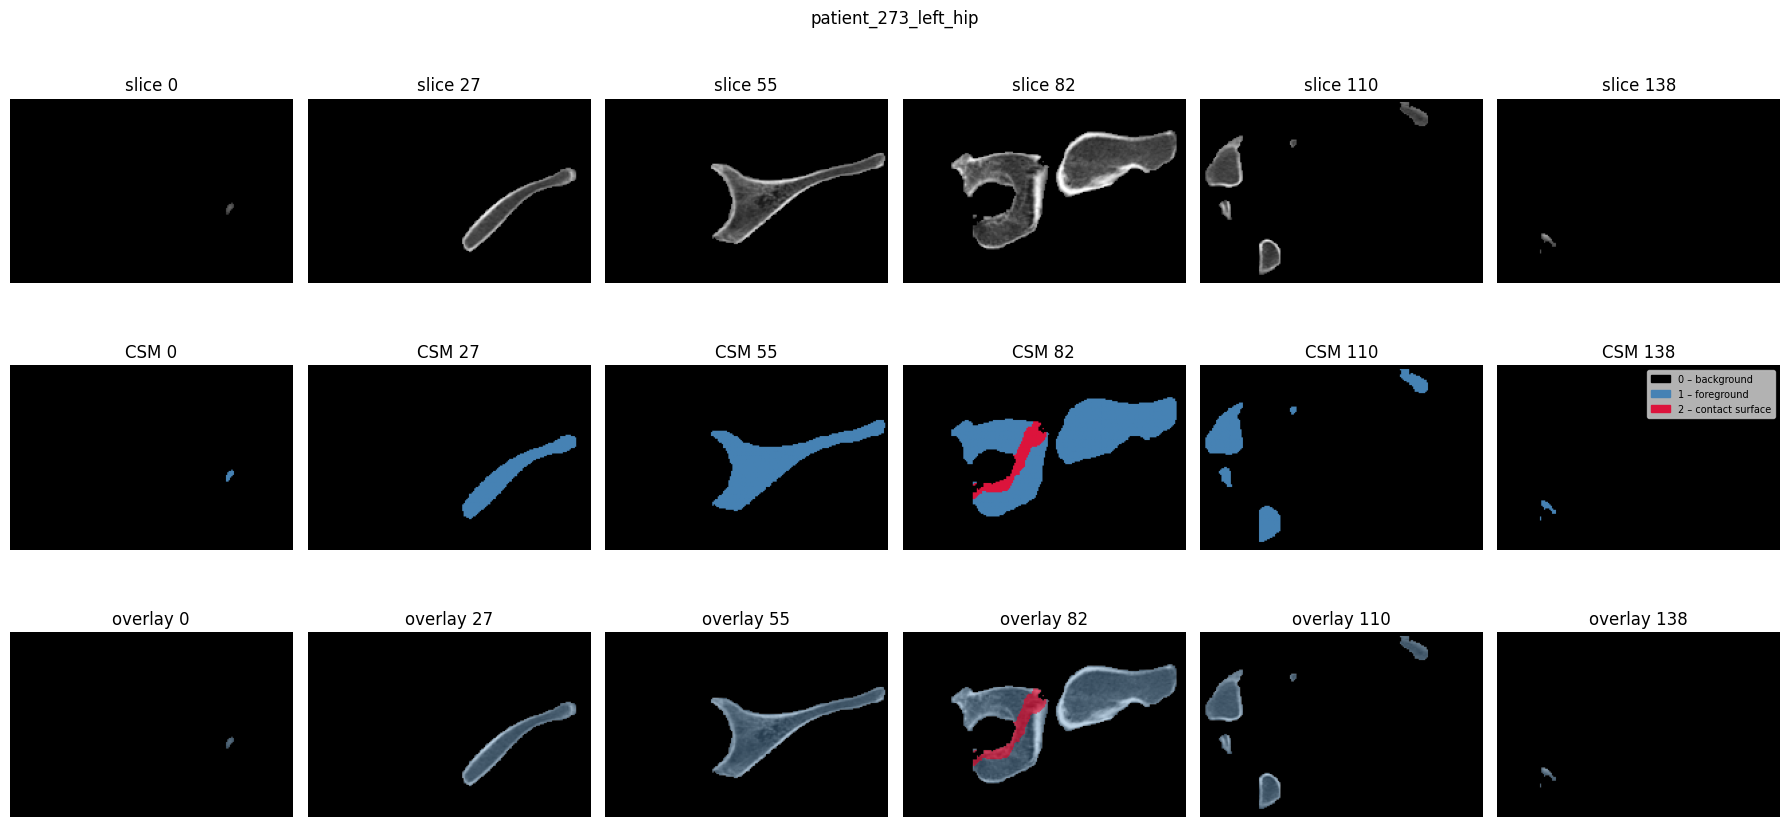

In [12]:
val_files = sorted(VAL_DIR.glob("patient_*.npz"))
print(f"Total validation volumes: {len(val_files)}")

for path in random.sample(val_files, min(3, len(val_files))):
    image, csm = check_sample(path)
    visualise_volume_slices(image, csm, title=path.stem)